# Task 1 - Step 4: Frozen backbones, linear heads and CLIP zero-shot

This is the **first notebook that touches a recognition model**. All evaluation images (clean and
transformed) were fixed in notebooks 01-03 without any model in the loop.

1. Load the three frozen backbones and extract their final representation:

| Backbone | Weights | Representation | Dim |
|---|---|---|---|
| torchvision ResNet-50 | `ResNet50_Weights.IMAGENET1K_V2` | global-average-pooled feature (`fc -> Identity`) | 2048 |
| torchvision ViT-B/16 | `ViT_B_16_Weights.IMAGENET1K_V1` | final class token (`heads -> Identity`) | 768 |
| OpenCLIP ViT-B-32 | `pretrained='openai'` | L2-normalised image embedding | 512 |

2. Train one linear head per backbone on the 80/20 split of the official STL-10 training partition
   (AdamW, lr 1e-3, weight decay 1e-4, <= 50 epochs, early stopping after 5 epochs without
   validation-accuracy improvement, seed 6304).
3. Build the CLIP zero-shot classifier with the fixed prompt from the config (no prompt search).
4. Run all four systems on every cached intervention set and save features + class probabilities,
   so notebooks 05 and 06 read **identical outputs**.

Every backbone receives the same uint8 224x224 image and applies **its own normalisation after the
intervention**. (The torchvision reference transforms resize to 232/256 and centre-crop 224; we
skip that because the common intervention image is already 224x224, as the manual requires.)

In [1]:
# ---- Common header (identical in every Task 1 notebook) ----
import json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Locate the task1/ folder no matter where Jupyter was launched from.
ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT / "task1" / "configs").exists():
    ROOT = ROOT / "task1"

CFG = json.loads((ROOT / "configs" / "task1_config.json").read_text())
SEED = CFG["seed"]

# Small, git-tracked outputs -> results/.  Large tensors/weights/raw data -> cache/ and data/ (git-ignored).
RES = ROOT / "results"
CACHE = ROOT / "cache"
DATA = ROOT / "data"
for p in [RES / "subset", RES / "cue_conflicts", RES / "tables", RES / "figures",
          CACHE / "sets", CACHE / "features", CACHE / "heads", CACHE / "weights", DATA]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=SEED):
    """Fix every RNG we use so reruns reproduce the same numbers."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print("ROOT:", ROOT, "| device:", DEVICE, "| seed:", SEED)

ROOT: C:\Users\afifh\Desktop\ATML\PA1\task1 | device: cuda | seed: 6304


In [2]:
import os, copy, time
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from torchvision.datasets import STL10
from torchvision.models import resnet50, ResNet50_Weights, vit_b_16, ViT_B_16_Weights
import open_clip

# Smoke mode (set env TASK1_SMOKE=1): 200 head-training images and 2 epochs, to test the pipeline quickly.
SMOKE = os.environ.get("TASK1_SMOKE", "0") == "1"
HC = CFG["head"]
MAX_EPOCHS = 2 if SMOKE else HC["max_epochs"]

subset = json.loads((RES / "subset" / "subset_ids.json").read_text())
CLASSES = subset["classes"]
OUT = CACHE / "outputs"
OUT.mkdir(exist_ok=True)
print("SMOKE:", SMOKE, "| classes:", CLASSES)

SMOKE: False | classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


## 4.1 Frozen backbones

`FrozenBackbone` maps a uint8 `[B,3,224,224]` batch to the final representation. Parameters are
frozen (`requires_grad=False`) and the modules stay in `eval()` mode throughout.

In [3]:
class FrozenBackbone(nn.Module):
    """uint8 images -> model-specific normalisation -> frozen encoder -> representation."""

    def __init__(self, encoder, mean, std, l2_normalize=False):
        super().__init__()
        self.encoder = encoder
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1))
        self.l2_normalize = l2_normalize

    @torch.no_grad()
    def forward(self, x_u8):
        x = (x_u8.float().div(255) - self.mean) / self.std
        f = self.encoder(x).float()
        return F.normalize(f, dim=-1) if self.l2_normalize else f


class CLIPImageEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model

    def forward(self, x):
        return self.clip_model.encode_image(x)


rn_w, vit_w = ResNet50_Weights.IMAGENET1K_V2, ViT_B_16_Weights.IMAGENET1K_V1
rn = resnet50(weights=rn_w); rn.fc = nn.Identity()            # -> global-average-pooled 2048-d feature
vit = vit_b_16(weights=vit_w); vit.heads = nn.Identity()      # -> final (layer-normed) class token, 768-d
clip_model, _, _ = open_clip.create_model_and_transforms(CFG["clip"]["model"], pretrained=CFG["clip"]["pretrained"])

BACKBONES = {
    "resnet50": FrozenBackbone(rn, rn_w.transforms().mean, rn_w.transforms().std),
    "vit_b16": FrozenBackbone(vit, vit_w.transforms().mean, vit_w.transforms().std),
    "clip_vitb32": FrozenBackbone(CLIPImageEncoder(clip_model), open_clip.OPENAI_DATASET_MEAN,
                                  open_clip.OPENAI_DATASET_STD, l2_normalize=True),
}
for name, bb in BACKBONES.items():
    bb.to(DEVICE).eval()
    for p in bb.parameters():
        p.requires_grad_(False)

# Sanity: output dims and frozen parameters
probe = torch.zeros(2, 3, 224, 224, dtype=torch.uint8, device=DEVICE)
DIMS = {k: bb(probe).shape[1] for k, bb in BACKBONES.items()}
assert DIMS == {"resnet50": 2048, "vit_b16": 768, "clip_vitb32": 512}, DIMS
assert all(not p.requires_grad for bb in BACKBONES.values() for p in bb.parameters())
print("feature dims:", DIMS)

feature dims: {'resnet50': 2048, 'vit_b16': 768, 'clip_vitb32': 512}


## 4.2 Head-training features (official STL-10 train partition, 80/20 split from notebook 01)

Images go through the **same** resize as the evaluation subset (bicubic to 224x224, uint8) and are
streamed in chunks, so no extra image cache is written.

In [4]:
train_ds = STL10(root=str(DATA), split="train", download=True)
train_labels = np.asarray(train_ds.labels)
split = json.loads((RES / "subset" / "head_split.json").read_text())
tr_idx, va_idx = np.asarray(split["train_idx"]), np.asarray(split["val_idx"])
if SMOKE:
    tr_idx, va_idx = tr_idx[:160], va_idx[:40]

resize224 = T.Compose([T.Resize((224, 224), interpolation=InterpolationMode.BICUBIC), T.PILToTensor()])  # as in notebook 01


@torch.no_grad()
def extract_u8(images_u8, chunk=100):
    """Features of every backbone for a uint8 tensor [N,3,224,224]."""
    feats = {k: [] for k in BACKBONES}
    for s in range(0, len(images_u8), chunk):
        x = images_u8[s:s + chunk].to(DEVICE)
        for k, bb in BACKBONES.items():
            feats[k].append(bb(x).cpu())
    return {k: torch.cat(v) for k, v in feats.items()}


def extract_train(indices, chunk=100):
    parts = [extract_u8(torch.stack([resize224(train_ds[int(i)][0]) for i in indices[s:s + chunk]]))
             for s in range(0, len(indices), chunk)]
    return {k: torch.cat([p[k] for p in parts]) for k in BACKBONES}


t0 = time.time()
F_tr, F_va = extract_train(tr_idx), extract_train(va_idx)
y_tr, y_va = torch.as_tensor(train_labels[tr_idx]), torch.as_tensor(train_labels[va_idx])
torch.save({"train": F_tr, "val": F_va, "y_train": y_tr, "y_val": y_va, "train_idx": tr_idx, "val_idx": va_idx},
           CACHE / "features" / "head_train_features.pt")
print(f"train {len(tr_idx)} / val {len(va_idx)} features in {time.time() - t0:.0f}s")

train 4000 / val 1000 features in 68s


## 4.3 Linear heads

One `nn.Linear(d, 10)` per backbone. Model selection uses **validation accuracy on the STL-10 train
partition only**; the 500-image test subset is never seen here. The best-validation state is restored
before evaluation. Full per-epoch curves are logged.

In [5]:
def train_head(Xtr, ytr, Xva, yva):
    set_seed()
    head = nn.Linear(Xtr.shape[1], len(CLASSES)).to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=HC["lr"], weight_decay=HC["weight_decay"])
    g = torch.Generator().manual_seed(SEED)
    Xtr, ytr, Xva, yva = Xtr.to(DEVICE), ytr.to(DEVICE), Xva.to(DEVICE), yva.to(DEVICE)
    log = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, best_epoch, bad = -1.0, None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        head.train()
        perm = torch.randperm(len(Xtr), generator=g).to(DEVICE)
        tot_loss, tot_correct = 0.0, 0
        for s in range(0, len(Xtr), HC["batch_size"]):
            b = perm[s:s + HC["batch_size"]]
            logits = head(Xtr[b])
            loss = F.cross_entropy(logits, ytr[b])
            opt.zero_grad(); loss.backward(); opt.step()
            tot_loss += loss.item() * len(b); tot_correct += (logits.argmax(1) == ytr[b]).sum().item()
        head.eval()
        with torch.no_grad():
            vl = head(Xva)
            val_loss, val_acc = F.cross_entropy(vl, yva).item(), (vl.argmax(1) == yva).float().mean().item()
        log["train_loss"].append(tot_loss / len(Xtr)); log["train_acc"].append(tot_correct / len(Xtr))
        log["val_loss"].append(val_loss); log["val_acc"].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state, best_epoch, bad = val_acc, copy.deepcopy(head.state_dict()), epoch, 0
        else:
            bad += 1
            if bad >= HC["patience"]:
                break
    head.load_state_dict(best_state)
    head.eval()
    return head, {**log, "best_epoch": best_epoch, "best_val_acc": best_acc, "epochs_run": epoch,
                  "stopped_early": epoch < MAX_EPOCHS}


HEADS, HEAD_LOG = {}, {}
for k in BACKBONES:
    HEADS[k], HEAD_LOG[k] = train_head(F_tr[k], y_tr, F_va[k], y_va)
    torch.save(HEADS[k].state_dict(), CACHE / "heads" / f"{k}_head.pt")
    L = HEAD_LOG[k]
    print(f"{k:12s} best epoch {L['best_epoch']:2d}/{L['epochs_run']:2d}  best val acc {L['best_val_acc']:.4f}")

(RES / "tables" / "task1_head_training_log.json").write_text(json.dumps({
    "config": {**HC, "max_epochs_used": MAX_EPOCHS, "optimizer": "AdamW", "seed": SEED,
               "selection_metric": "val_acc (STL-10 train partition, 20% split)",
               "n_train": int(len(tr_idx)), "n_val": int(len(va_idx)), "smoke": SMOKE},
    "heads": HEAD_LOG}, indent=1))

resnet50     best epoch 15/20  best val acc 0.9720


vit_b16      best epoch 19/24  best val acc 0.9790


clip_vitb32  best epoch  4/ 9  best val acc 0.9840


5521

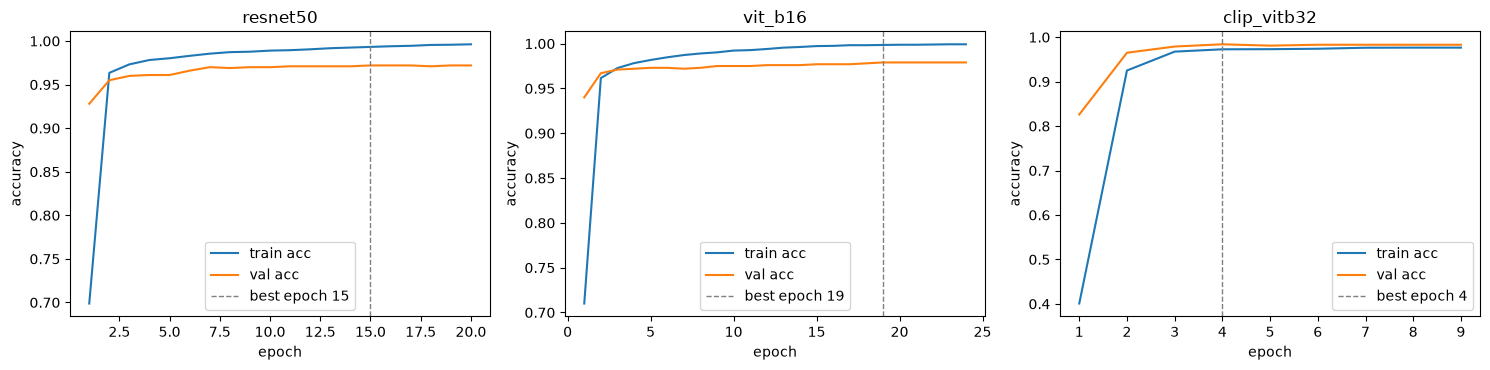

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, k in zip(axes, BACKBONES):
    L = HEAD_LOG[k]; ep = np.arange(1, len(L["val_acc"]) + 1)
    ax.plot(ep, L["train_acc"], label="train acc"); ax.plot(ep, L["val_acc"], label="val acc")
    ax.axvline(L["best_epoch"], ls="--", c="gray", lw=1, label=f"best epoch {L['best_epoch']}")
    ax.set_title(k); ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.legend()
plt.tight_layout()
fig.savefig(RES / "figures" / "task1_head_training_curves.png", dpi=150, bbox_inches="tight")
fig.savefig(RES / "figures" / "task1_head_training_curves.pdf", bbox_inches="tight"); plt.show()

## 4.4 CLIP zero-shot classifier

Text embeddings for the fixed prompt (manual: *"a photo of a {class}."*, read from the config, no
prompt search). Zero-shot logits are `logit_scale.exp() * <image_emb, text_emb>`; confidence is the
softmax over these scaled similarities, as the manual specifies.

In [7]:
tokenizer = open_clip.get_tokenizer(CFG["clip"]["model"])
PROMPTS = [CFG["clip"]["prompt"].format(c) for c in CLASSES]
with torch.no_grad():
    TXT = F.normalize(clip_model.encode_text(tokenizer(PROMPTS).to(DEVICE)).float(), dim=-1).cpu()
    LOGIT_SCALE = float(clip_model.logit_scale.exp().item())
torch.save({"text_emb": TXT, "logit_scale": LOGIT_SCALE, "prompts": PROMPTS}, CACHE / "heads" / "clip_zeroshot.pt")
(RES / "tables" / "task1_clip_prompts.json").write_text(json.dumps({"prompts": PROMPTS, "logit_scale": LOGIT_SCALE}, indent=1))
print(PROMPTS, "| logit scale", LOGIT_SCALE)

['a photo of a airplane.', 'a photo of a bird.', 'a photo of a car.', 'a photo of a cat.', 'a photo of a deer.', 'a photo of a dog.', 'a photo of a horse.', 'a photo of a monkey.', 'a photo of a ship.', 'a photo of a truck.'] | logit scale 100.0


## 4.5 Features and class probabilities for every intervention set

Every set was generated in notebooks 01-03 and is index-aligned with the clean subset (except the
cue-conflict set, which keeps `content_idx`/`style_idx` pointers into the clean subset).

In [8]:
tr_cfg = CFG["translation"]
SET_NAMES = (["clean", "grayscale", "hue_rotate", "patch_shuffle", "cue_conflict"] +
             [f"translate_{d}_{s}" for s in tr_cfg["displacements"] for d in tr_cfg["directions"]])
missing = [n for n in SET_NAMES if not (CACHE / "sets" / f"{n}.pt").exists()]
assert not missing, f"run notebooks 01-03 first; missing sets: {missing}"

t0 = time.time()
FEATS = {k: {} for k in BACKBONES}
for name in SET_NAMES:
    f = extract_u8(torch.load(CACHE / "sets" / f"{name}.pt")["images"])
    for k in BACKBONES:
        FEATS[k][name] = f[k]
print(f"extracted {len(SET_NAMES)} sets x {len(BACKBONES)} backbones in {time.time() - t0:.0f}s")

# System = (backbone, classifier). CLIP is evaluated with its trained head AND zero-shot.
SYSTEMS = {"resnet50_head": "resnet50", "vit_b16_head": "vit_b16", "clip_head": "clip_vitb32", "clip_zeroshot": "clip_vitb32"}


@torch.no_grad()
def logits_of(system, X):
    if system == "clip_zeroshot":
        return LOGIT_SCALE * X @ TXT.T
    return HEADS[SYSTEMS[system]](X.to(DEVICE)).cpu()


PROBS = {s: {n: logits_of(s, FEATS[bb][n]).softmax(1) for n in SET_NAMES} for s, bb in SYSTEMS.items()}

clean_blob = torch.load(CACHE / "sets" / "clean.pt")
cc_blob = torch.load(CACHE / "sets" / "cue_conflict.pt")
torch.save({"features": FEATS, "dims": DIMS}, CACHE / "features" / "task1_eval_features.pt")
torch.save({
    "classes": CLASSES, "labels": clean_blob["labels"], "test_indices": clean_blob["test_indices"],
    "cue_conflict": {k: cc_blob[k] for k in ["shape_label", "texture_label", "content_idx", "style_idx"]},
    "systems": list(SYSTEMS), "backbone_of": SYSTEMS, "set_names": SET_NAMES, "probs": PROBS,
    "smoke": SMOKE}, OUT / "task1_outputs.pt")
print("saved features and outputs")

extracted 17 sets x 3 backbones in 106s


saved features and outputs


In [9]:
# Quick sanity print (read-only: nothing below changes any model, head, image or setting).
y = clean_blob["labels"].numpy()
for s in SYSTEMS:
    print(f"{s:14s} clean top-1 = {(PROBS[s]['clean'].argmax(1).numpy() == y).mean():.4f}")

resnet50_head  clean top-1 = 0.9700
vit_b16_head   clean top-1 = 0.9680
clip_head      clean top-1 = 0.9680
clip_zeroshot  clean top-1 = 0.9360
